# AutoEncoder: A Comprehensive Guide

An AutoEncoder is a type of neural network trained to learn efficient representations of data by compressing it into a lower-dimensional 'latent space' (encoding) and then reconstructing it (decoding). It's a powerful unsupervised technique for dimensionality reduction, feature learning, and anomaly detection.

In this notebook, we'll cover:
1. Basic concepts of AutoEncoders
2. Data preparation and visualization
3. AutoEncoder implementation from scratch using NumPy
4. Applications: dimensionality reduction and anomaly detection
5. Model evaluation and visualization

# Simple Explanation: What Does the Code Below Do?

Imagine you need to send a large file over a slow internet connection. You compress it first, send it, and then decompress it at the other end. An AutoEncoder does exactly the same thing with data!

Architecture:
- **Encoder**: Neural network layers that compress input → smaller representation (bottleneck)
- **Bottleneck (Latent Space)**: The compressed representation
- **Decoder**: Neural network layers that decompress the bottleneck → reconstructed output

Training: The autoencoder learns by minimizing the difference between input and output (reconstruction error). It must learn what's important to keep and what's not.

Applications:
- **Dimensionality reduction**: Like PCA but can learn non-linear compressions.
- **Anomaly detection**: If an anomaly has high reconstruction error, it's unusual!
- **Denoising**: Train to reconstruct clean data from noisy inputs.
- **Data generation**: Variational AutoEncoders (VAEs) can generate new data.

Here's what the code does:
1. Implements a simple AutoEncoder from scratch with NumPy.
2. Applies it to digit images for compression and visualization.
3. Shows anomaly detection using reconstruction error.

In short: AutoEncoders learn to encode the most essential features of data for perfect reconstruction!

In [1]:
import os
import sys

venv_dir = 'ml_env'
if not os.path.exists(venv_dir):
    os.system(f'{sys.executable} -m venv {venv_dir}')
    print(f'Virtual environment created at {venv_dir}')
else:
    print(f'Virtual environment already exists at {venv_dir}')

pip_path = os.path.join(venv_dir, 'Scripts', 'pip')
if sys.platform == 'win32':
    pip_path += '.exe'

if os.path.exists(pip_path):
    os.system(f'"{pip_path}" install numpy pandas matplotlib seaborn scikit-learn')
    print('Required libraries installed.')
else:
    print('Could not find pip. Please check your Python installation.')

Virtual environment created at ml_env
Required libraries installed.


# 1. Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# 2. Generating Sample Data

We'll use the Digits dataset (8x8 pixel images of handwritten digits = 64 features).

Dataset shape: (1797, 64)
Feature range: [0.00, 1.00]


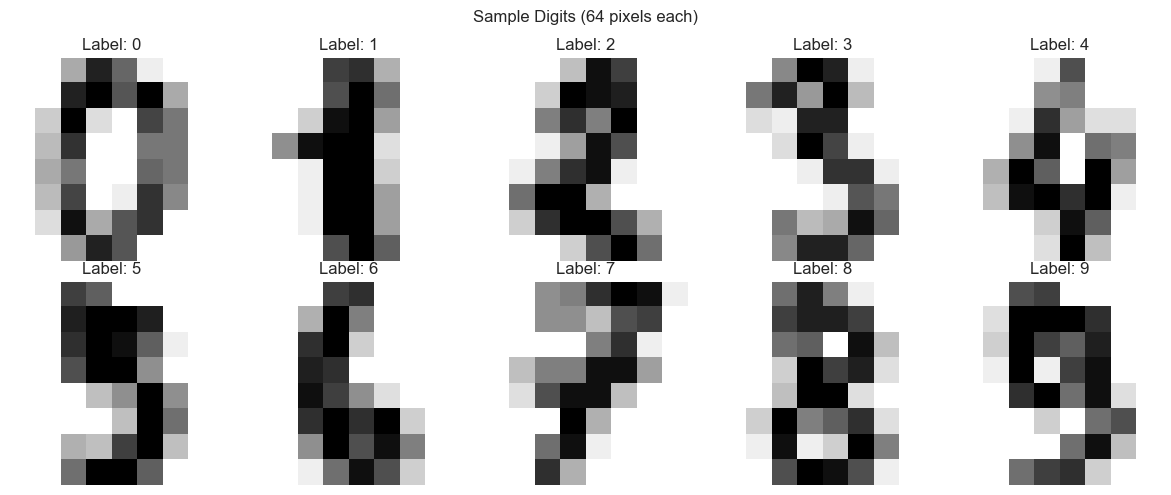

In [3]:
digits = load_digits()
X, y = digits.data, digits.target

# Scale to [0, 1] — important for autoencoder with sigmoid activation
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f'Dataset shape: {X.shape}')
print(f'Feature range: [{X_scaled.min():.2f}, {X_scaled.max():.2f}]')

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Visualize a few sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.suptitle('Sample Digits (64 pixels each)')
plt.tight_layout()
plt.show()

# 3. Implementing AutoEncoder from Scratch

We implement a simple 2-layer autoencoder:
- Encoder: 64 → 32 → latent_dim
- Decoder: latent_dim → 32 → 64

Training objective: Minimize reconstruction error (MSE between input and output).

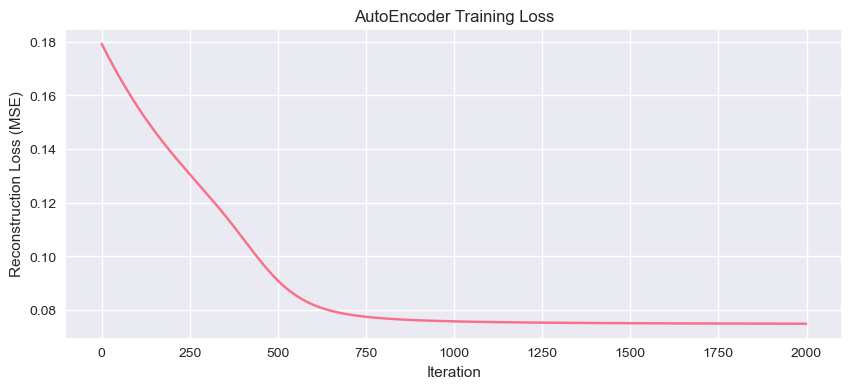

Final training loss: 0.074904


In [4]:
class AutoEncoderScratch:
    def __init__(self, input_dim=64, latent_dim=8, hidden_dim=32, 
                 learning_rate=0.01, n_iterations=1000):
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.history = {'loss': []}
        np.random.seed(42)

        # Encoder weights
        self.W_enc1 = np.random.randn(input_dim, hidden_dim) * 0.01
        self.b_enc1 = np.zeros((1, hidden_dim))
        self.W_enc2 = np.random.randn(hidden_dim, latent_dim) * 0.01
        self.b_enc2 = np.zeros((1, latent_dim))

        # Decoder weights
        self.W_dec1 = np.random.randn(latent_dim, hidden_dim) * 0.01
        self.b_dec1 = np.zeros((1, hidden_dim))
        self.W_dec2 = np.random.randn(hidden_dim, input_dim) * 0.01
        self.b_dec2 = np.zeros((1, input_dim))

    def _relu(self, z): return np.maximum(0, z)
    def _relu_deriv(self, a): return (a > 0).astype(float)
    def _sigmoid(self, z): return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def encode(self, X):
        h1 = self._relu(X @ self.W_enc1 + self.b_enc1)
        z = self._relu(h1 @ self.W_enc2 + self.b_enc2)
        return h1, z

    def decode(self, z):
        h2 = self._relu(z @ self.W_dec1 + self.b_dec1)
        out = self._sigmoid(h2 @ self.W_dec2 + self.b_dec2)
        return h2, out

    def fit(self, X):
        for iteration in range(self.n_iterations):
            # Forward pass
            h_enc1, z = self.encode(X)
            h_dec1, X_recon = self.decode(z)

            # Loss (MSE)
            loss = np.mean((X - X_recon) ** 2)
            self.history['loss'].append(loss)

            # Backward pass (simplified)
            m = X.shape[0]
            dout = -2 * (X - X_recon) / m
            dout_sig = dout * X_recon * (1 - X_recon)  # sigmoid deriv

            dW_dec2 = h_dec1.T @ dout_sig
            db_dec2 = dout_sig.sum(axis=0, keepdims=True)
            dh_dec1 = dout_sig @ self.W_dec2.T * self._relu_deriv(h_dec1)
            dW_dec1 = z.T @ dh_dec1
            db_dec1 = dh_dec1.sum(axis=0, keepdims=True)

            dz = dh_dec1 @ self.W_dec1.T * self._relu_deriv(z)
            dW_enc2 = h_enc1.T @ dz
            db_enc2 = dz.sum(axis=0, keepdims=True)
            dh_enc1 = dz @ self.W_enc2.T * self._relu_deriv(h_enc1)
            dW_enc1 = X.T @ dh_enc1
            db_enc1 = dh_enc1.sum(axis=0, keepdims=True)

            # Update
            for w, dw in [(self.W_enc1, dW_enc1), (self.b_enc1, db_enc1),
                          (self.W_enc2, dW_enc2), (self.b_enc2, db_enc2),
                          (self.W_dec1, dW_dec1), (self.b_dec1, db_dec1),
                          (self.W_dec2, dW_dec2), (self.b_dec2, db_dec2)]:
                w -= self.lr * dw

    def reconstruct(self, X):
        _, z = self.encode(X)
        _, X_recon = self.decode(z)
        return X_recon

    def get_latent(self, X):
        _, z = self.encode(X)
        return z

# Train the autoencoder
ae = AutoEncoderScratch(input_dim=64, latent_dim=8, hidden_dim=32, 
                        learning_rate=0.01, n_iterations=2000)
ae.fit(X_train)

# Plot training loss
plt.figure(figsize=(10, 4))
plt.plot(ae.history['loss'])
plt.xlabel('Iteration')
plt.ylabel('Reconstruction Loss (MSE)')
plt.title('AutoEncoder Training Loss')
plt.grid(True)
plt.show()

final_loss = ae.history['loss'][-1]
print(f'Final training loss: {final_loss:.6f}')

# 4. Using Scikit-learn AutoEncoder (via MLPRegressor)

We can use sklearn's MLPRegressor to build a more optimized autoencoder pipeline.

Reconstruction MSE (sklearn AE): 0.034887


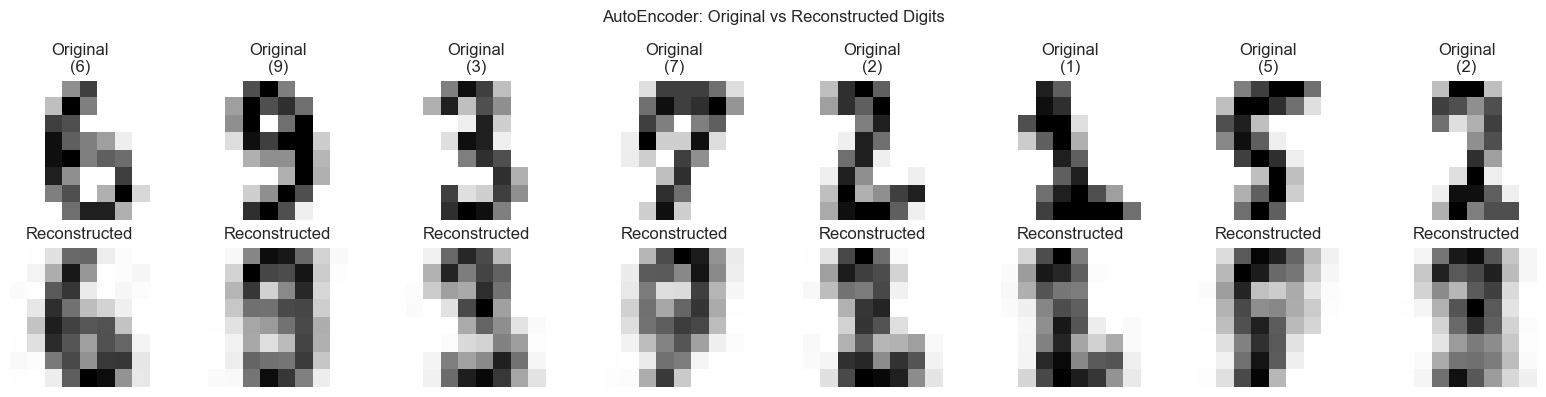

In [5]:
# Use MLPRegressor as encoder (we split into encoder/decoder manually)
# Full AE: input → 32 → 8 → 32 → input 
ae_sklearn = MLPRegressor(hidden_layer_sizes=(32, 8, 32), max_iter=500,
                           activation='relu', solver='adam', random_state=42,
                           learning_rate_init=0.001)

# Train: predict input from input (reconstruction)
ae_sklearn.fit(X_train, X_train)

# Reconstruct test set
X_recon = ae_sklearn.predict(X_test)
X_recon = np.clip(X_recon, 0, 1)  # clip to valid range

recon_mse = mean_squared_error(X_test, X_recon)
print(f'Reconstruction MSE (sklearn AE): {recon_mse:.6f}')

# Show reconstructions
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(16, 4))
for i in range(n_show):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap='gray_r')
    axes[0, i].set_title(f'Original\n({y_test[i]})')
    axes[0, i].axis('off')

    axes[1, i].imshow(X_recon[i].reshape(8, 8), cmap='gray_r')
    axes[1, i].set_title('Reconstructed')
    axes[1, i].axis('off')

plt.suptitle('AutoEncoder: Original vs Reconstructed Digits')
plt.tight_layout()
plt.show()

# 5. Model Evaluation — Anomaly Detection with Reconstruction Error

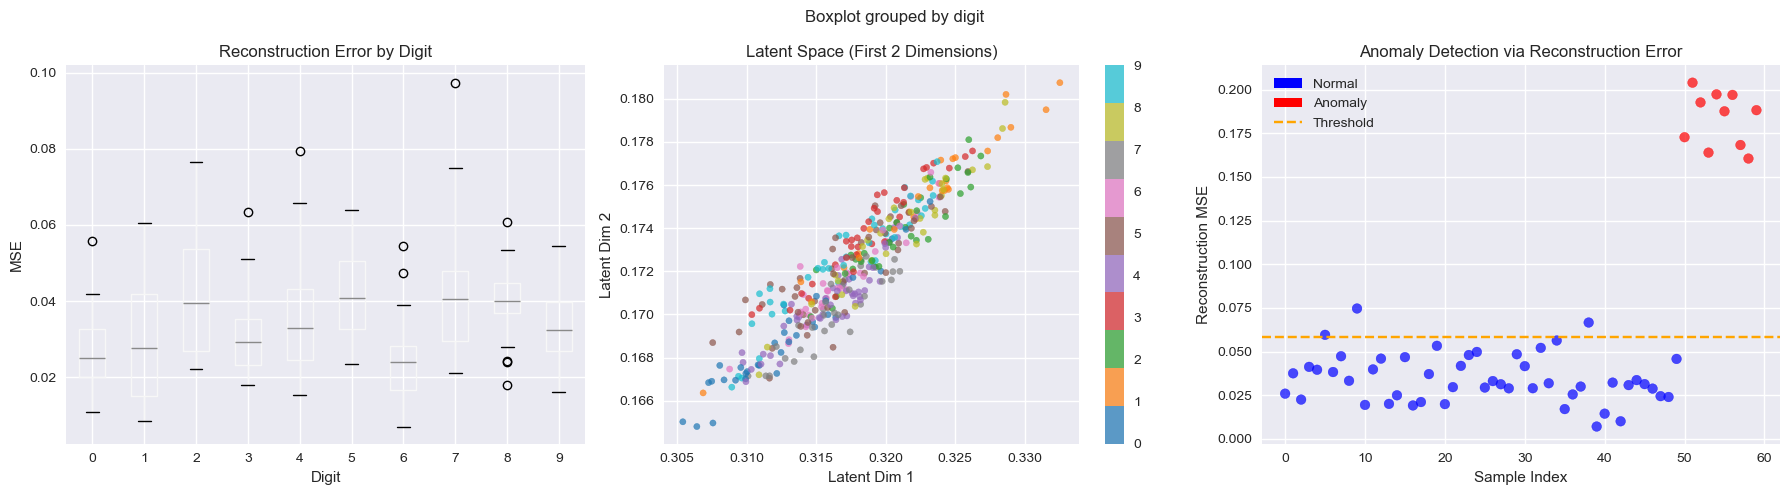


Key Insights:
- Low reconstruction error = normal (model has seen similar patterns).
- High reconstruction error = anomaly (model struggles to reconstruct it).
- Latent space clusters similar digits close together.
- AutoEncoders are powerful for unsupervised feature learning!


In [6]:
# Reconstruction error for each test sample
recon_errors = np.mean((X_test - X_recon) ** 2, axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Reconstruction Error Distribution by Digit
df_errors = pd.DataFrame({'digit': y_test, 'recon_error': recon_errors})
df_errors.boxplot(column='recon_error', by='digit', ax=axes[0])
axes[0].set_title('Reconstruction Error by Digit')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('MSE')

# 2. Latent Space Visualization (from scratch AE, 8D → 2D projection)
Z_test = ae.get_latent(X_test)
# Use first 2 latent dimensions
scatter = axes[1].scatter(Z_test[:, 0], Z_test[:, 1], c=y_test, cmap='tab10', alpha=0.7, s=20)
plt.colorbar(scatter, ax=axes[1])
axes[1].set_title('Latent Space (First 2 Dimensions)')
axes[1].set_xlabel('Latent Dim 1')
axes[1].set_ylabel('Latent Dim 2')

# 3. Anomaly Detection: High reconstruction error = outlier
# Simulate anomalies by adding random noise to some test samples
X_normal = X_test[:50]
X_anomaly = np.random.uniform(0, 1, (10, 64))  # random images (anomalies)
X_all = np.vstack([X_normal, X_anomaly])
labels_true = ['Normal'] * 50 + ['Anomaly'] * 10

recon_all = ae_sklearn.predict(X_all)
recon_all = np.clip(recon_all, 0, 1)
errors_all = np.mean((X_all - recon_all) ** 2, axis=1)

colors = ['blue' if l == 'Normal' else 'red' for l in labels_true]
axes[2].scatter(range(len(errors_all)), errors_all, c=colors, alpha=0.7)
axes[2].axhline(y=np.percentile(errors_all[:50], 95), color='orange', 
                linestyle='--', label='95th percentile threshold')
axes[2].set_title('Anomaly Detection via Reconstruction Error')
axes[2].set_xlabel('Sample Index')
axes[2].set_ylabel('Reconstruction MSE')
# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='blue', label='Normal'), 
                   Patch(facecolor='red', label='Anomaly')]
axes[2].legend(handles=legend_elements + [plt.Line2D([0], [0], color='orange', linestyle='--', label='Threshold')])

plt.tight_layout()
plt.show()

print('\nKey Insights:')
print('- Low reconstruction error = normal (model has seen similar patterns).')
print('- High reconstruction error = anomaly (model struggles to reconstruct it).')
print('- Latent space clusters similar digits close together.')
print('- AutoEncoders are powerful for unsupervised feature learning!')

# Conclusions and Key Takeaways
Autoencoders are an unsupervised artificial neural network architecture used primarily for representation learning and dimensionality reduction. They work by compressing the input into a lower-dimensional code (latent space) and then reconstructing the output from that representation.
- **Bottleneck**: The crucial feature is the hidden layer bottleneck that forces the network to capture only the most essential features of the data.
- **Applications**: Widely used for anomaly detection, image denoising, dimensionality reduction (often outperforming PCA on non-linear data), and generative modeling (Variational Autoencoders).

# Pros and Cons
**Pros:**
- Highly effective at uncovering complex, non-linear relationships, unlike PCA which is strictly linear.
- Self-supervised: Does not require manual labels, as the input data itself serves as the target output.
- Easily adaptable for specific tasks like denoising images or filling in missing data simply by feeding corrupted input while targeting clean output.

**Cons:**
- Tends to be a "black box," making the learned latent features extremely difficult to interpret.
- Computationally expensive to train compared to standard PCA.
- Prone to just "memorizing" the data (copying input to output) if the bottleneck isn't tight enough or if it's over-parameterized without regularization.

# 15 Interview Questions and Answers

1. **What is an Autoencoder?**
   *Answer*: A type of neural network that learns to compress input data into a lower-dimensional latent representation and then reconstruct it back to its original form as closely as possible.

2. **What are the main components of an Autoencoder?**
   *Answer*: The Encoder (compresses the input), the Bottleneck/Latent Space (the compressed representation), and the Decoder (reconstructs the input).

3. **Why do we need a bottleneck layer?**
   *Answer*: Without a bottleneck (a layer with significantly fewer nodes than the input), the network could just explicitly memorize the input and copy it directly to the output without learning any meaningful underlying patterns.

4. **How does an Autoencoder differ from PCA?**
   *Answer*: PCA is restricted to finding linear transformations that maximize variance. An Autoencoder with non-linear activation functions can learn complex, non-linear manifold representations of the data. However, a purely linear autoencoder essentially learns the same subspace as PCA.

5. **What is the typical loss function used for an Autoencoder?**
   *Answer*: Mean Squared Error (MSE) is used when the input deals with continuous values. Binary Cross-Entropy is used when the inputs are scaled between 0 and 1 (like normalized pixel intensities).

6. **What is a Denoising Autoencoder?**
   *Answer*: An autoencoder trained to reconstruct the original, clean data from a deliberately corrupted or noisy version of the input data. This forces the model to learn truly robust features rather than just memorizing.

7. **What is a Sparse Autoencoder?**
   *Answer*: An autoencoder that uses regularization (like an L1 penalty on the activations of the hidden layer) to force only a small number of nodes to be active at once. It can allow the hidden layer to actually be larger than the input layer while still preventing plain memorization.

8. **What is a Variational Autoencoder (VAE)?**
   *Answer*: A generative variant that doesn't just learn a discrete point in the latent space, but instead learns to map inputs to a probability distribution (mean and variance). You can then sample from this distribution to generate entirely new, realistic data.

9. **How is an Autoencoder used for Anomaly Detection?**
   *Answer*: You train the autoencoder exclusively on normal, healthy data. When presented with anomalous data, the autoencoder won't recognize the patterns and will yield a significantly higher reconstruction error, flagging it as an anomaly.

10. **What is the "Reconstruction Error"?**
    *Answer*: The mathematical difference (often measured by MSE) between the original input `x` and the decoded output `x'`.

11. **Can Autoencoders be used for feature extraction in supervised learning pipelines?**
    *Answer*: Yes. The encoder portion can be extracted after training on unlabelled data, and the latent representations can be fed as highly discriminative features into a standard classifier, like a Random Forest or Logistic Regression.

12. **What is an Undercomplete Autoencoder?**
    *Answer*: The standard autoencoder where the dimension of the latent space (bottleneck) is strictly less than the dimension of the input space.

13. **What is an Overcomplete Autoencoder?**
    *Answer*: An autoencoder where the hidden layer has *more* dimensions than the input. Without strict regularization (like sparsity or denoising criteria), it will trivially learn the identity function.

14. **Why might you use an Autoencoder instead of a Convolutional Neural Network (CNN)?**
    *Answer*: They aren't mutually exclusive! You frequently build Convolutional Autoencoders, using CNN layers in both the encoder and decoder to handle image data much more effectively than standard dense layers.

15. **What is KL Divergence in the context of VAEs?**
    *Answer*: Kullback-Leibler Divergence is used as a regularization term in the VAE loss function. It forces the learned latent distributions to closely track a standard normal distribution, keeping the latent space smooth and continuous for data generation.
